Defaulting to user installation because normal site-packages is not writeable


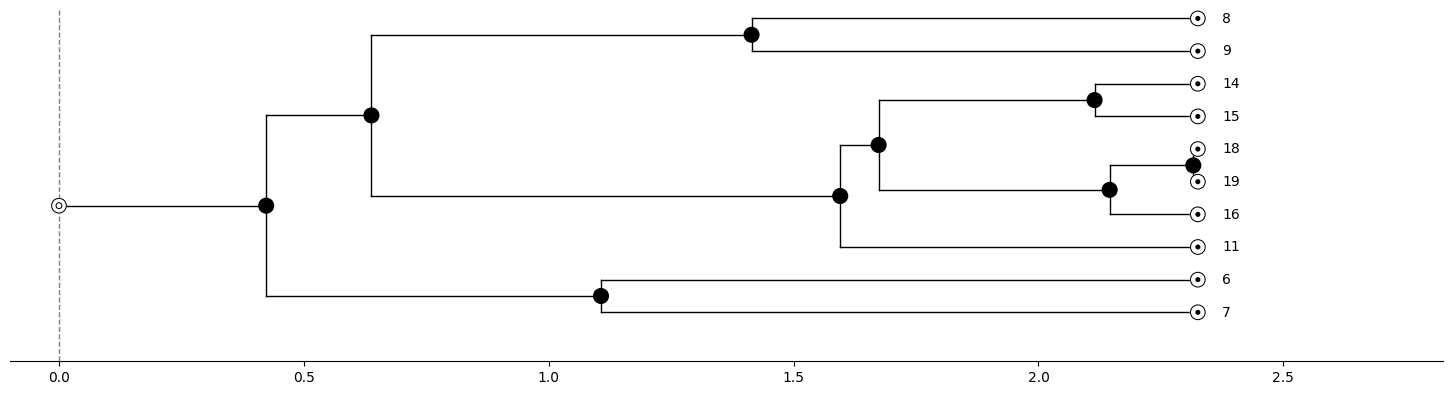

In [257]:
!pip install asymmetree

import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize

# simulate a species tree with 10 leaves
S1 = te.species_tree_n(10)

visualize(S1)

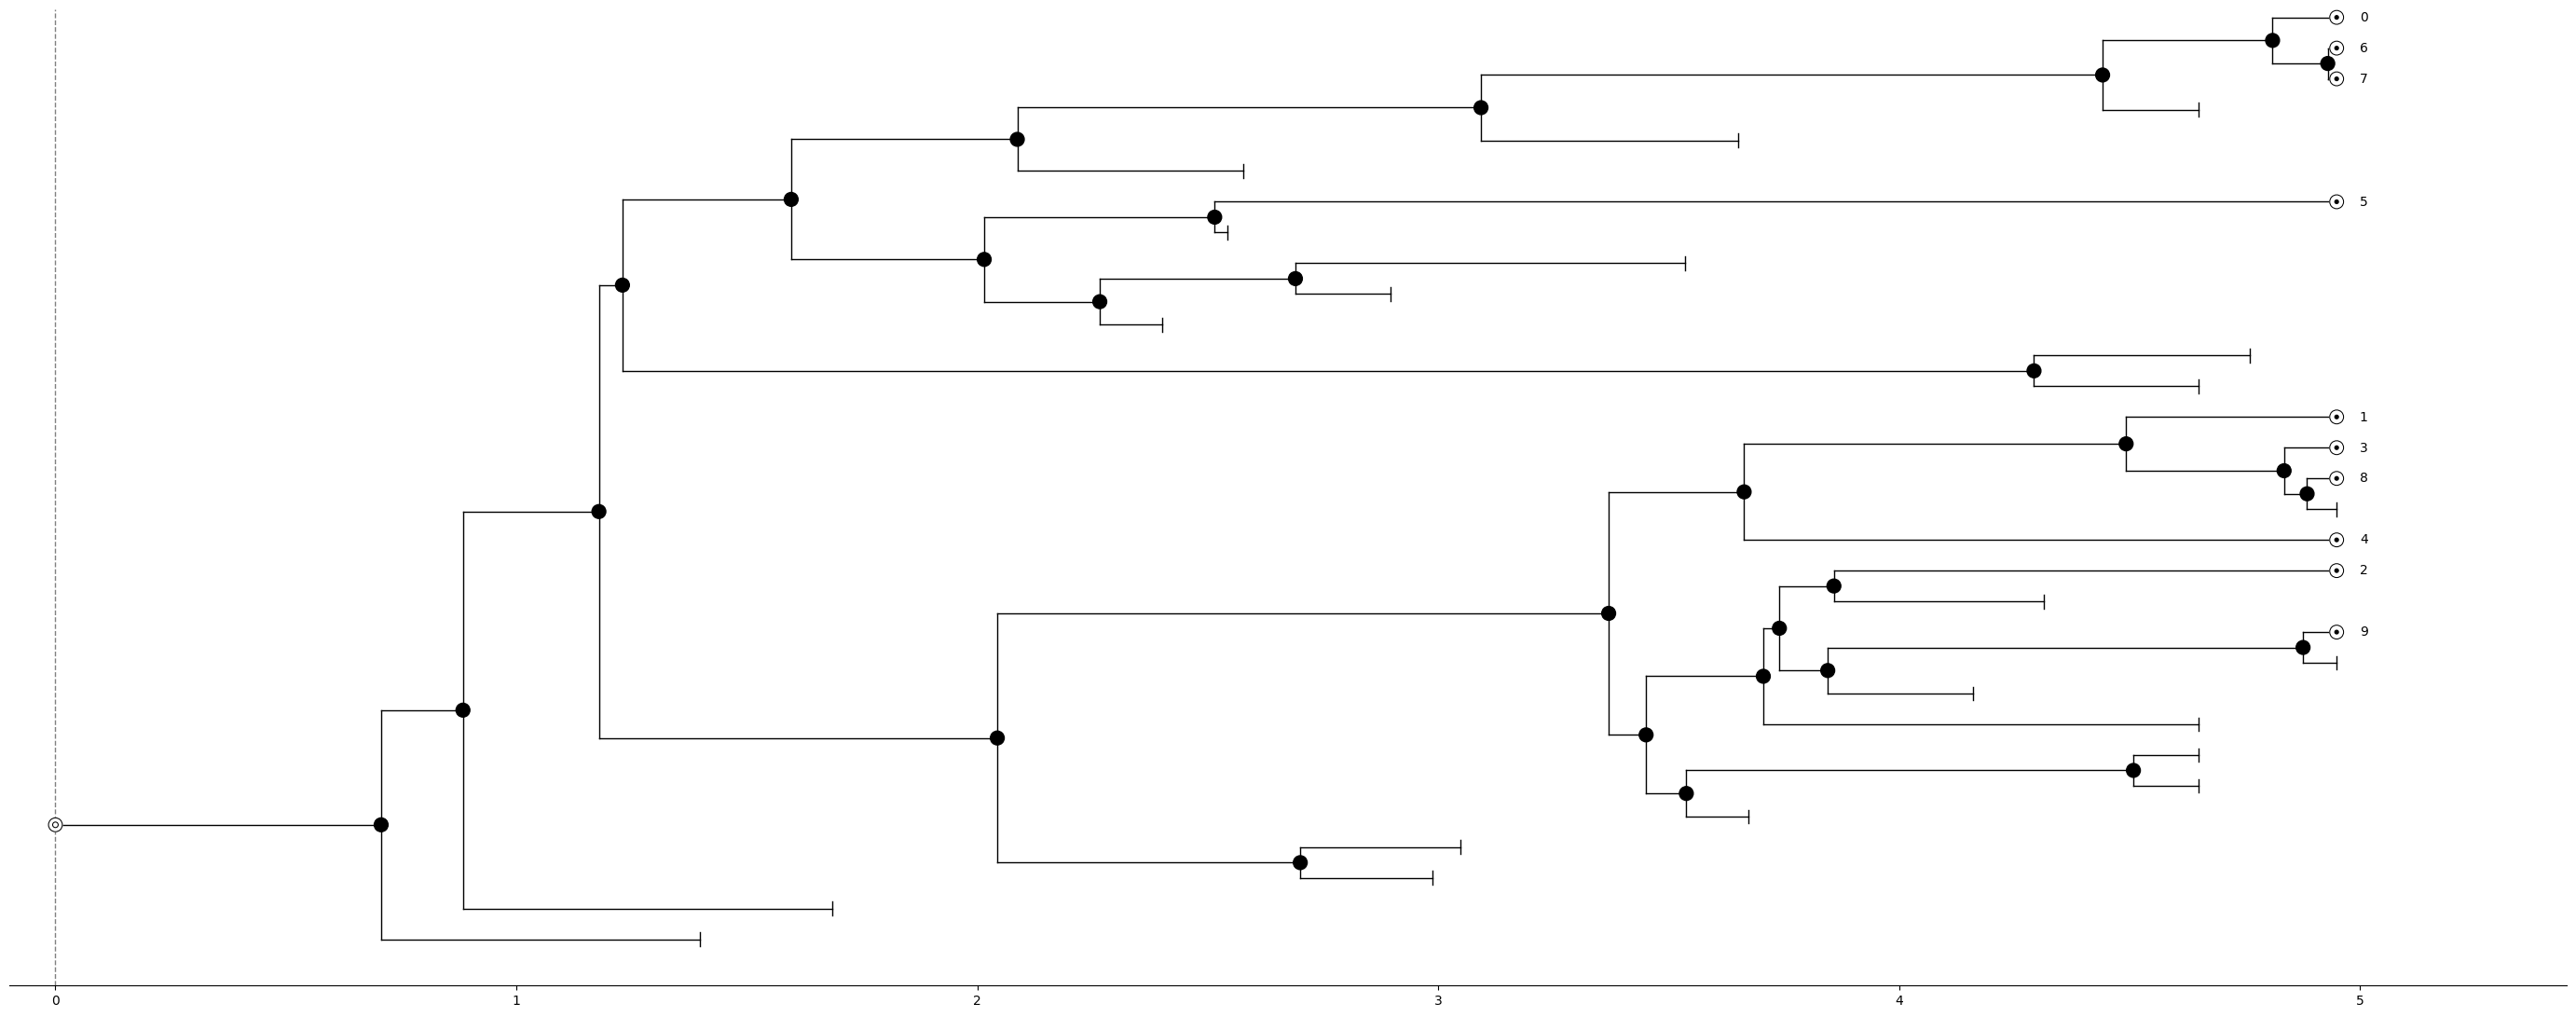

In [3]:

S2 = te.species_tree_n(   
  10,  # number of (extant) species leaves
  model="EBDP",  # episodic birth-death process
  episodes=[ # birthrate, deathrate, proportion of survivors, time stamp
    (1.0, 0.3, 0.8, 0.0),
    (0.9, 0.4, 0.6, 0.3),
  ])

visualize(S2)

### Inserting a hybrid vertex

Here comes the problem of "time traveling" as we must ensure for every hybrid vertex we add after the first, some sort of time traveling is not possible

Situation:

- Existierende Kante A -> C
- Ziel: Einführen B zwischen der Kante A und C, so dass A -> B -> C 
- Dafür: 
  - Beziehung A->C löschen
  - Beziehung A->B hinzufügen
  - Beziehung B->C hinzufügen
- Problem: Knoten muss erstmal eingeführt werden
  - Zwischen A und C (Timestamp!)

---

Welche Attribute haben die TreeNodes?
- Label::int
- event::str
- tstamp::float
- dist::float

Müssen die manuell gesetzt werden?

### Timestamps
- Root hat größten Timestamp und Leaves den kleinsten (= 0?)



[('label', 1), ('event', 'S'), ('tstamp', 0.81686830233888), ('dist', 0.24491940405873935)]


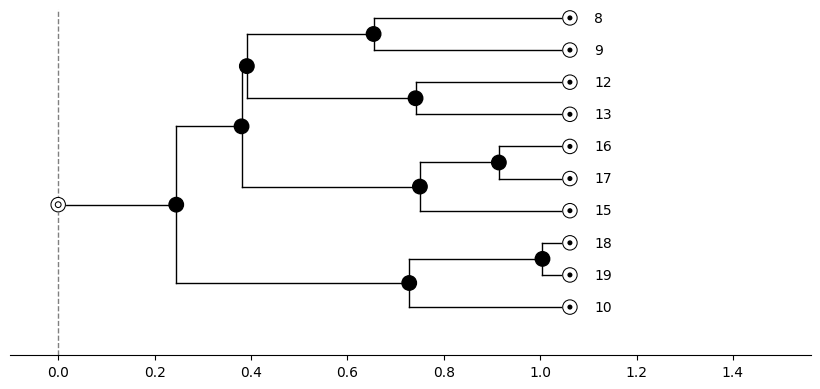

In [37]:
# 1. Kante erstellen zwsichen zwei Knoten mit random time stamp

from random import random
from random import uniform
from tralda.datastructures import Tree, TreeNode

for first, second in S1.edges():
    if first.__str__() == "1" and second.__str__() == "2":
        timestamp_first = [y for x,y in first.attributes() if x == "tstamp"]
        timestamp_second = [y for x,y in second.attributes() if x == "tstamp"]
        print(list(first.attributes()))

visualize(S1)        

Time stamps of edge 1, vertex 1:  0.21088733345084298
Time stamps of edge 1, vertex 2:  0.0
Time stamps of edge 2, vertex 1:  0.9112865413466629
Time stamps of edge 2, vertex 2:  0.0
Distance of edge 1:  0.21088733345084298
Distance of edge 2:  0.9112865413466629
The new node can be added because the time stamps of the edges are consistent.
Min parent time stamp:  0.21088733345084298
Max child time stamp:  0.0
New hybrid vertex timestamp: 0.20582915927120377
Distance to new node: 0.5610869373987529


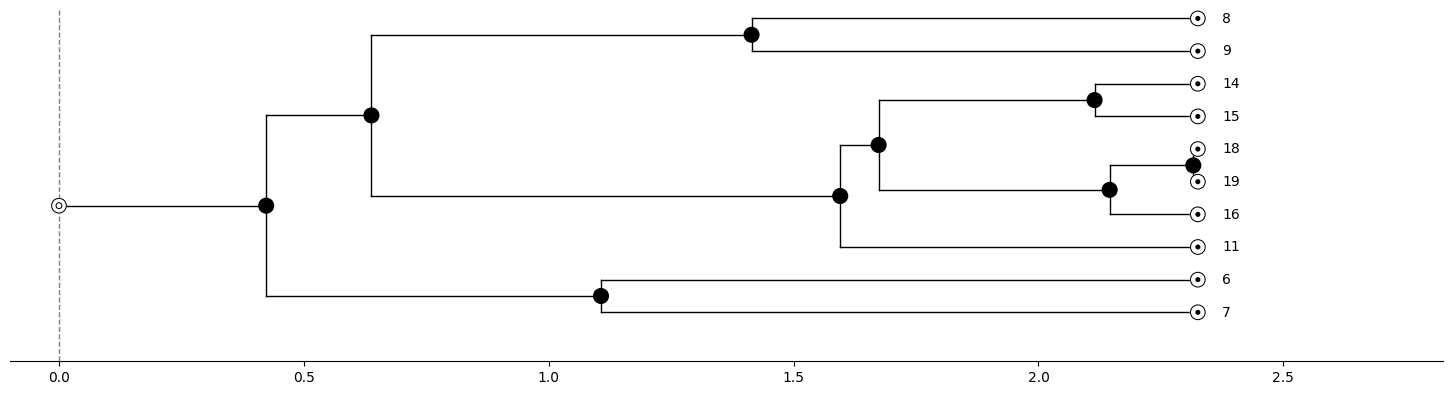

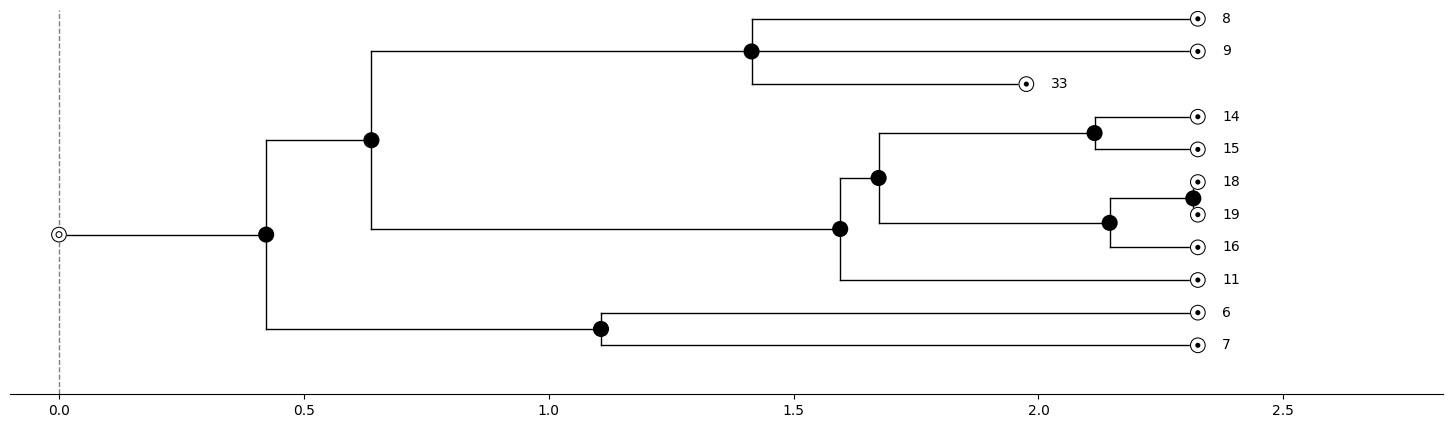

(<TN: 0>, <TN: 1>)
(<TN: 1>, <TN: 3>)
(<TN: 3>, <TN: 5>)
(<TN: 5>, <TN: 8>)
(<TN: 5>, <TN: 9>)
(<TN: 5>, <TN: 33>)
(<TN: 3>, <TN: 4>)
(<TN: 4>, <TN: 10>)
(<TN: 10>, <TN: 13>)
(<TN: 13>, <TN: 14>)
(<TN: 13>, <TN: 15>)
(<TN: 10>, <TN: 12>)
(<TN: 12>, <TN: 17>)
(<TN: 17>, <TN: 18>)
(<TN: 17>, <TN: 19>)
(<TN: 12>, <TN: 16>)
(<TN: 4>, <TN: 11>)
(<TN: 1>, <TN: 2>)
(<TN: 2>, <TN: 6>)
(<TN: 2>, <TN: 7>)


In [ ]:
# Beispiel Implementierung

import random
import copy

## Iterieren über alle Kanten des Baums

S1_new = copy.deepcopy(S1) # Create a copy of the tree to modify

edges = S1_new.edges() # Is an iterator, so we need to convert it to a list to be able to pick random edges
edges = list(edges)

# Pick two random edges

edge1 = random.choice(edges)
edge2 = random.choice(edges)

# Ensure that the two edges are different
while edge1 == edge2:
    edge2 = random.choice(edges)

# Get the time stamps of the two edges
## important when understood what's the constraint

### Calculate the time stamps of the two vertices of the edges
tstamp_e1_v1 = list(edge1[0].attributes())[2][1]
dist_e1 = list(edge1[1].attributes())[3][1]
tstamp_e1_v2 = list(edge1[1].attributes())[2][1]
tstamp_e2_v1 = list(edge2[0].attributes())[2][1]
dist_e2 = list(edge2[1].attributes())[3][1]
tstamp_e2_v2 = list(edge2[1].attributes())[2][1]

print("Time stamps of edge 1, vertex 1: ", tstamp_e1_v1)
print("Time stamps of edge 1, vertex 2: ", tstamp_e1_v2)
print("Time stamps of edge 2, vertex 1: ", tstamp_e2_v1)
print("Time stamps of edge 2, vertex 2: ", tstamp_e2_v2)
print("Distance of edge 1: ", dist_e1)
print("Distance of edge 2: ", dist_e2)

# Consistency check

parents = min(float(tstamp_e1_v1), float(tstamp_e2_v1))
childs = max(float(tstamp_e1_v2), float(tstamp_e2_v2))

if parents <= childs: 
    print("Error: The new node cannot be added because the time stamps of the edges are not consistent.")
    print("Min parent time stamp: ", parents)
    print("Max child time stamp: ", childs)
    # Later, exit or raise an exception
else:
    print("The new node can be added because the time stamps of the edges are consistent.")
    print("Min parent time stamp: ", parents)
    print("Max child time stamp: ", childs)
    # Now calculate the hybrid node timestamp as a random value between parents and childs
    vertex_timestamp = uniform(parents, childs)
    print(f"New hybrid vertex timestamp: {vertex_timestamp}")

# Calculate distances for the new 

dist_to_new = (dist_e1 + dist_e2) / 2 
print(f"Distance to new node: {dist_to_new}")

new_node = TreeNode(label="33", dist=dist_to_new, event=None, tstamp=vertex_timestamp)

# Add new node

#child1 = edge1[1]
#child2 = edge2[1]

#edge1[0].remove_child(edge1[1])
#edge2[0].remove_child(edge2[1])

# 2. Add new node to the original parents
#edge1[0].add_child(new_node)
#edge2[0].add_child(new_node)

# 3. Add the disconnected children to the new node
#new_node.add_child(edge1[1])
#new_node.add_child(edge2[1])

# Done
#visualize(S1)
#visualize(S1_new)


Defaulting to user installation because normal site-packages is not writeable


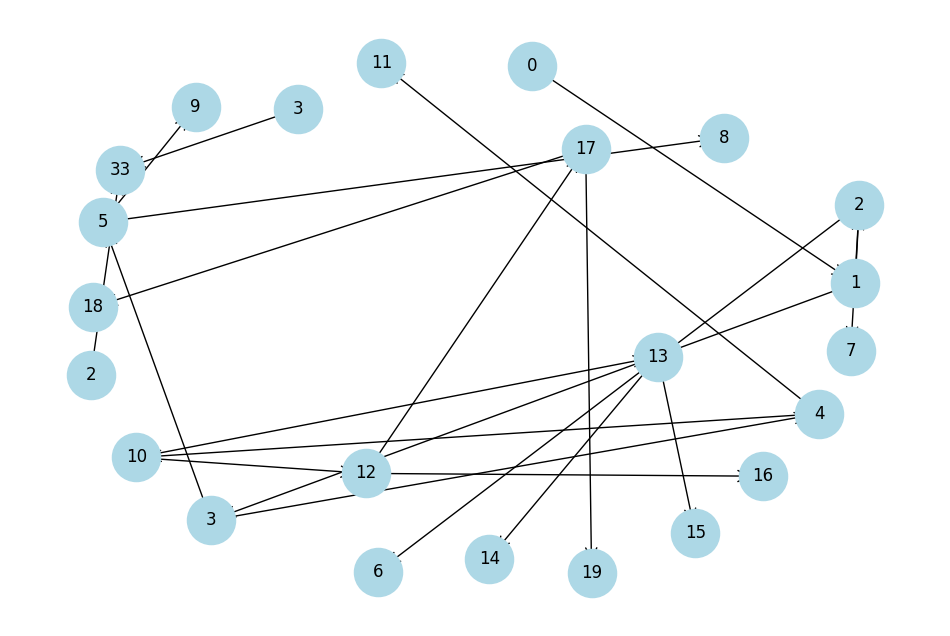

In [272]:
!pip install networkx matplotlib

import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt

G = nx.DiGraph()
for parent, child in S1.edges():
    G.add_edge(parent.label, child.label)

G.add_edge("2", "33")
G.add_edge("3", "33")

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42, k=2)

nx.draw_networkx_nodes(
    G, pos,
    node_color="lightblue",
    node_size=1200
)

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowstyle='->',
    arrowsize=20
)

nx.draw_networkx_labels(G, pos)

plt.axis("off")
plt.show()